# Phase 1 — Data Preparation

**Steps 1.1 – 1.6** from the CartIQ proposal.

| Step | Description |
|---|---|
| 1.1 | Download Instacart CSV files and load into Pandas DataFrames |
| 1.2 | Merge orders, order_products__prior, and products tables |
| 1.3 | Handle missing values (days_since_prior_order NaN → 0) |
| 1.4 | Construct supervised label from order_products__train |
| 1.5 | Perform train / val / test split (80 / 10 / 10 by user) |
| 1.6 | Verify class imbalance ratio and document |

**Prerequisite:** Place Instacart CSV files in `ml/data/`. See `ml/data/README.md`.

In [2]:
# Install dependencies (run once, or: pip install -r ../requirements.txt)
# !pip install pandas numpy scikit-learn lightgbm optuna shap matplotlib seaborn pyarrow tqdm -q

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR      = '../data'
FEATURES_DIR  = '../features'
OUTPUTS_DIR   = '../outputs'

for d in [FEATURES_DIR, OUTPUTS_DIR]:
    os.makedirs(d, exist_ok=True)

sns.set_style('darkgrid')
print('Setup complete.')

Setup complete.


## Step 1.1 — Load CSV Files

In [3]:
print('Loading Instacart CSV files...')

orders      = pd.read_csv(f'{DATA_DIR}/orders.csv')
op_prior    = pd.read_csv(f'{DATA_DIR}/order_products__prior.csv')
op_train    = pd.read_csv(f'{DATA_DIR}/order_products__train.csv')
products    = pd.read_csv(f'{DATA_DIR}/products.csv')
departments = pd.read_csv(f'{DATA_DIR}/departments.csv')
aisles      = pd.read_csv(f'{DATA_DIR}/aisles.csv')

print(f'orders:      {orders.shape}')
print(f'op_prior:    {op_prior.shape}')
print(f'op_train:    {op_train.shape}')
print(f'products:    {products.shape}')
print(f'departments: {departments.shape}')
print(f'aisles:      {aisles.shape}')
print()
print('eval_set distribution:')
print(orders['eval_set'].value_counts())

Loading Instacart CSV files...
orders:      (3421083, 7)
op_prior:    (32434489, 4)
op_train:    (1384617, 4)
products:    (49688, 4)
departments: (21, 2)
aisles:      (134, 2)

eval_set distribution:
eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64


## Step 1.2 — Merge Tables

In [4]:
prior_orders = orders[orders['eval_set'] == 'prior']

prior = op_prior.merge(prior_orders, on='order_id')
prior = prior.merge(
    products[['product_id', 'product_name', 'aisle_id', 'department_id']],
    on='product_id'
)
prior = prior.merge(departments, on='department_id')
prior = prior.merge(aisles, on='aisle_id')

print(f'Merged prior dataset: {prior.shape}')
print(prior.dtypes)
prior.head(3)

Merged prior dataset: (32434489, 15)
order_id                    int64
product_id                  int64
add_to_cart_order           int64
reordered                   int64
user_id                     int64
eval_set                   object
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
product_name               object
aisle_id                    int64
department_id               int64
department                 object
aisle                      object
dtype: object


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,department,aisle
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,dairy eggs,eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,produce,fresh vegetables
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,pantry,spices seasonings


## Step 1.3 — Handle Missing Values

In [5]:
n_missing = prior['days_since_prior_order'].isna().sum()
print(f'Missing days_since_prior_order: {n_missing:,}')
print('(These are each user\'s very first order — no prior order exists)')

prior['days_since_prior_order'] = prior['days_since_prior_order'].fillna(0)
print('Filled NaN with 0.')
print(f'Remaining NaN: {prior["days_since_prior_order"].isna().sum()}')

Missing days_since_prior_order: 2,078,068
(These are each user's very first order — no prior order exists)
Filled NaN with 0.
Remaining NaN: 0


## Step 1.4 — Construct Supervised Label

In [6]:
train_orders = orders[orders['eval_set'] == 'train'][['order_id', 'user_id']]
train_labels = op_train.merge(train_orders, on='order_id')[['user_id', 'product_id', 'reordered']]

# All (user, product) pairs ever purchased in prior — these are our candidates
user_product_prior = (
    prior.groupby(['user_id', 'product_id'])
         .size()
         .reset_index(name='times_ordered_prior')
)

# Left-join train labels: pairs not in train order get label = 0
label_df = user_product_prior.merge(
    train_labels, on=['user_id', 'product_id'], how='left'
)
label_df['reordered'] = label_df['reordered'].fillna(0).astype(int)

print(f'Total candidate (user, product) pairs: {len(label_df):,}')
print(f'Positive labels (reordered=1):          {label_df["reordered"].sum():,}')
label_df.head()

Total candidate (user, product) pairs: 13,307,953
Positive labels (reordered=1):          828,824


,user_id,product_id,times_ordered_prior,reordered
0,1,196,10,1
1,1,10258,9,1
2,1,10326,1,0
3,1,12427,10,0
4,1,13032,3,1


## Step 1.5 — Train / Val / Test Split

In [7]:
# Split at user level: 80% train, 10% val, 10% test
train_user_ids = train_labels['user_id'].unique()
np.random.seed(42)
shuffled = np.random.permutation(train_user_ids)
n = len(shuffled)

train_users = set(shuffled[:int(0.8 * n)])
val_users   = set(shuffled[int(0.8 * n):int(0.9 * n)])
test_users  = set(shuffled[int(0.9 * n):])

label_df['split'] = 'train'
label_df.loc[label_df['user_id'].isin(val_users),  'split'] = 'val'
label_df.loc[label_df['user_id'].isin(test_users), 'split'] = 'test'

print('Split distribution (rows):')
print(label_df['split'].value_counts())
print()
print(f'Train users: {len(train_users):,}')
print(f'Val users:   {len(val_users):,}')
print(f'Test users:  {len(test_users):,}')

Split distribution (rows):
split
train    11616502
val        848147
test       843304
Name: count, dtype: int64

Train users: 104,967
Val users:   13,121
Test users:  13,121


## Step 1.6 — Class Imbalance Analysis

=== Class Imbalance ===
Positive (reordered=1):    828,824  (6.2%)
Negative (reordered=0): 12,479,129  (93.8%)
Neg : Pos ratio:        15.06 : 1
=> scale_pos_weight for LightGBM: 15.06


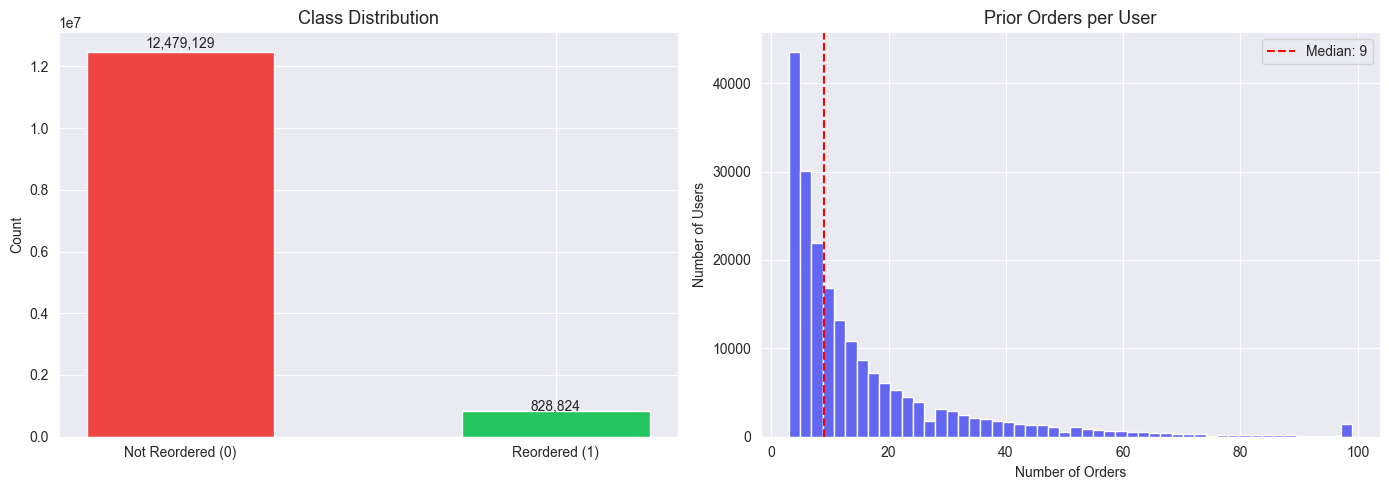

Plot saved.


In [8]:
pos   = int(label_df['reordered'].sum())
neg   = len(label_df) - pos
ratio = neg / pos

print('=== Class Imbalance ===')
print(f'Positive (reordered=1): {pos:>10,}  ({pos / len(label_df) * 100:.1f}%)')
print(f'Negative (reordered=0): {neg:>10,}  ({neg / len(label_df) * 100:.1f}%)')
print(f'Neg : Pos ratio:        {ratio:.2f} : 1')
print(f'=> scale_pos_weight for LightGBM: {ratio:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['Not Reordered (0)', 'Reordered (1)'],
            [neg, pos], color=['#ef4444', '#22c55e'], width=0.5)
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate([neg, pos]):
    axes[0].text(i, v * 1.01, f'{v:,}', ha='center', fontsize=10)

orders_per_user = (
    orders[orders['eval_set'] == 'prior']
    .groupby('user_id')['order_id'].count()
)
axes[1].hist(orders_per_user, bins=50, color='#6366f1', edgecolor='white')
axes[1].axvline(
    orders_per_user.median(), color='red', linestyle='--',
    label=f'Median: {int(orders_per_user.median())}'
)
axes[1].set_title('Prior Orders per User', fontsize=13)
axes[1].set_xlabel('Number of Orders')
axes[1].set_ylabel('Number of Users')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/01_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved.')

## Save Processed Data

In [9]:
print('Saving processed data to Parquet...')
prior.to_parquet(f'{FEATURES_DIR}/prior_merged.parquet', index=False)
label_df.to_parquet(f'{FEATURES_DIR}/labels.parquet', index=False)

print(f'  prior_merged.parquet  — {prior.shape[0]:,} rows')
print(f'  labels.parquet        — {len(label_df):,} rows')
print('Phase 1 complete. Proceed to 02_feature_engineering.ipynb')

Saving processed data to Parquet...
  prior_merged.parquet  — 32,434,489 rows
  labels.parquet        — 13,307,953 rows
Phase 1 complete. Proceed to 02_feature_engineering.ipynb
